# Weather Delay Classification
This notebook builds a classification model to predict the severity of weather-related flight delays.

**Sections:**
1. Setup & Imports
2. Data Loading & Filtering
3. Data Cleaning
4. Exploratory Analysis & Binning
5. Feature Engineering & Preprocessing
6. Model Training
7. Model Comparison & Evaluation

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb

plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42

## 2. Data Loading & Filtering

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/combined.csv')
print(f'Original dataset shape: {df.shape}')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original dataset shape: (3966862, 48)


,Carrier Code,date,destination_code,Scheduled elapsed time (Minutes),Actual elapsed time (Minutes),Departure delay (Minutes),Taxi-Out time (Minutes),origin_code,month,day_of_week,...,dest_PRCP,dest_SNDP,dest_SLP,dest_ELEVATION,dest_Fog,dest_Rain,dest_Snow,dest_Hail,dest_Thunder,dest_Tornado
0,DL,2024-01-01,DTW,110.0,92.0,12.0,12.0,EWR,1.0,0.0,...,0.02,0.0,1020.3,191.9,0.0,1.0,1.0,0.0,0.0,0.0
1,DL,2024-01-01,SLC,325.0,291.0,-5.0,23.0,EWR,1.0,0.0,...,0.00,0.0,1023.3,1288.4,0.0,0.0,0.0,0.0,0.0,0.0
2,DL,2024-01-01,MSP,184.0,152.0,-10.0,13.0,EWR,1.0,0.0,...,0.02,1.2,1026.8,254.5,0.0,0.0,0.0,0.0,0.0,0.0
3,DL,2024-01-01,MSP,194.0,161.0,4.0,20.0,EWR,1.0,0.0,...,0.02,1.2,1026.8,254.5,0.0,0.0,0.0,0.0,0.0,0.0
4,DL,2024-01-01,SLC,330.0,278.0,18.0,17.0,EWR,1.0,0.0,...,0.00,0.0,1023.3,1288.4,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Define weather event columns
COLS = [
    'origin_Fog', 'origin_Rain', 'origin_Snow',
    'origin_Hail', 'origin_Thunder', 'origin_Tornado',
    'dest_Fog', 'dest_Rain', 'dest_Snow',
    'dest_Hail', 'dest_Thunder', 'dest_Tornado'
]

# Keep flights that are weather delayed AND have at least one recorded weather event
has_weather_event = df[COLS].any(axis=1)
is_weather_delayed = df['weather_delayed'] == 1

delayed = df[is_weather_delayed & has_weather_event].copy()
delayed.to_csv('delayed.csv', index=False)

## 3. Data Cleaning

In [4]:
# Drop non-weather columns
COLS_TO_DROP = [
    'origin_lat', 'origin_lon', 'dest_lat', 'dest_lon',
    'origin_code', 'destination_code',
    'date',
    # Post-departure leakage columns
    'Actual elapsed time (Minutes)',
    'Taxi-Out time (Minutes)'
]

# Only drop columns that actually exist
COLS_TO_DROP = [c for c in COLS_TO_DROP if c in delayed.columns]
df_clean = delayed.drop(columns=COLS_TO_DROP)
print(f'After dropping irrelevant columns: {df_clean.shape}')

After dropping irrelevant columns: (37314, 39)


In [5]:
# Check and drop NAs
print('Missing values per column:')
missing = df_clean.isnull().sum()

df_clean = df_clean.dropna()
print(f'\nAfter dropping NAs: {df_clean.shape}')

Missing values per column:

After dropping NAs: (37023, 39)


## 4. Exploratory Analysis & Delay Bins

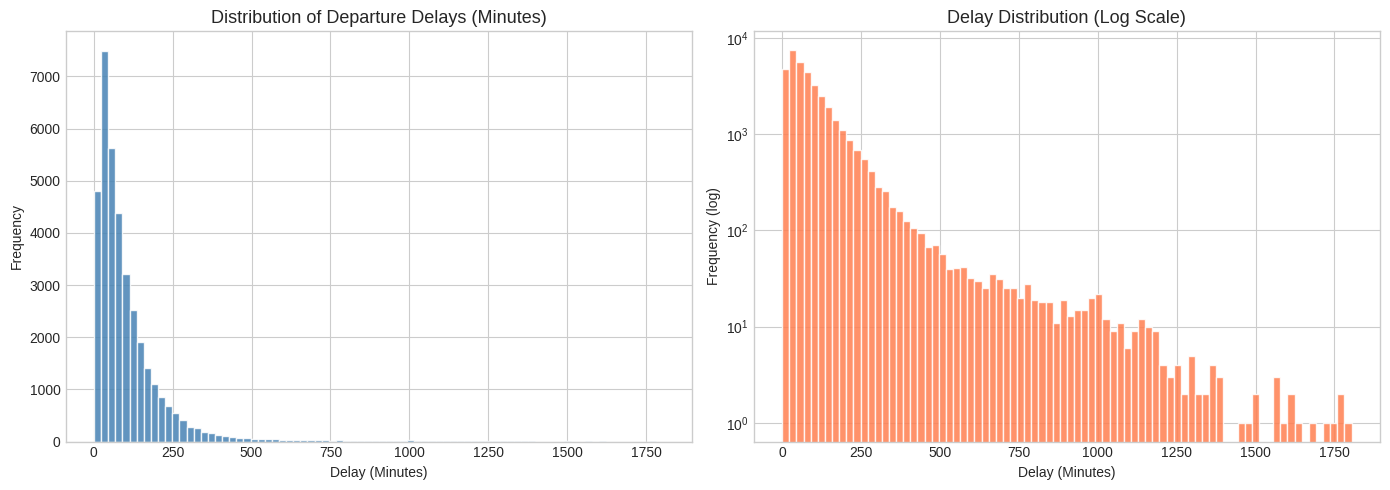

Delay statistics:
count    37023.000000
mean       109.147152
std        131.758127
min          1.000000
25%         37.000000
50%         71.000000
75%        134.000000
max       1804.000000
Name: Departure delay (Minutes), dtype: float64

Percentiles:
0.25     37.0
0.50     71.0
0.75    134.0
0.90    227.0
0.95    310.0
Name: Departure delay (Minutes), dtype: float64


In [6]:
delay_col = 'Departure delay (Minutes)'
delayed_only = df_clean[delay_col]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(delayed_only, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Departure Delays (Minutes)', fontsize=13)
axes[0].set_xlabel('Delay (Minutes)')
axes[0].set_ylabel('Frequency')

# Log scale to show long tail properly
axes[1].hist(delayed_only, bins=80, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_yscale('log')
axes[1].set_title('Delay Distribution (Log Scale)', fontsize=13)
axes[1].set_xlabel('Delay (Minutes)')
axes[1].set_ylabel('Frequency (log)')

plt.tight_layout()
plt.show()

print('Delay statistics:')
print(delayed_only.describe())
print('\nPercentiles:')
print(delayed_only.quantile([0.25, 0.5, 0.75, 0.90, 0.95]))

In [7]:
# Investigate extreme values
print(f'Flights with delay > 600 mins: {df_clean[df_clean[delay_col] > 600].shape[0]:,}')
print(f'Flights with delay > 300 mins: {df_clean[df_clean[delay_col] > 300].shape[0]:,}')

# Drop likely data errors (>600 mins)
df_clean = df_clean[df_clean[delay_col] <= 600].copy()
print(f'\nAfter removing extreme outliers: {df_clean.shape}')

# 3 bins — Minor absorbs the tiny Minimal class
bins = [0, 60, 120, float('inf')]
labels = ['Minor', 'Moderate', 'Severe']

df_clean['delay_class'] = pd.cut(
    df_clean[delay_col],
    bins=bins,
    labels=labels
)

print('\nClass distribution:')
print(df_clean['delay_class'].value_counts().sort_index())
print('\nClass proportions:')
print(df_clean['delay_class'].value_counts(normalize=True).sort_index().round(3))

Flights with delay > 600 mins: 525
Flights with delay > 300 mins: 1,966

After removing extreme outliers: (36498, 39)

Class distribution:
delay_class
Minor       16029
Moderate    10285
Severe      10184
Name: count, dtype: int64

Class proportions:
delay_class
Minor       0.439
Moderate    0.282
Severe      0.279
Name: proportion, dtype: float64


## 5. Feature Engineering & Preprocessing

In [8]:
# Drop the raw delay column and weather_delayed flag (target leakage)
FEATURES_TO_DROP = [delay_col, 'weather_delayed']
FEATURES_TO_DROP = [c for c in FEATURES_TO_DROP if c in df_clean.columns]

X = df_clean.drop(columns=FEATURES_TO_DROP + ['delay_class'])
y = df_clean['delay_class']

print(f'Feature matrix shape: {X.shape}')
print(f'Target classes: {y.unique()}')

Feature matrix shape: (36498, 37)
Target classes: ['Minor', 'Severe', 'Moderate']
Categories (3, object): ['Minor' < 'Moderate' < 'Severe']


In [9]:
# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Categorical columns to encode: {categorical_cols}')

# Train/test split BEFORE encoding
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Categorical columns to encode: ['Carrier Code']
Train size: (29198, 37), Test size: (7300, 37)


In [10]:
# One-hot encode AFTER split
if categorical_cols:
    X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
    X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
    # Align columns — test may be missing rare categories
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    print(f'After encoding — Train: {X_train.shape}, Test: {X_test.shape}')
else:
    print('No categorical columns found to encode.')

# Encode target labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
print(f'Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

After encoding — Train: (29198, 39), Test: (7300, 39)
Label encoding: {'Minor': np.int64(0), 'Moderate': np.int64(1), 'Severe': np.int64(2)}


In [11]:
# Feature engineering: interaction terms for weather severity
# Combine origin and destination continuous weather variables
weather_continuous = ['TEMP', 'DEWP', 'VISIB', 'WDSP', 'MXSPD', 'GUST', 'PRCP', 'SNDP', 'SLP']

for col in weather_continuous:
    orig = f'origin_{col}'
    dest = f'dest_{col}'
    if orig in X_train.columns and dest in X_train.columns:
        # Average weather severity across origin + destination
        X_train[f'avg_{col}'] = (X_train[orig] + X_train[dest]) / 2
        X_test[f'avg_{col}'] = (X_test[orig] + X_test[dest]) / 2
        # Max severity
        X_train[f'max_{col}'] = X_train[[orig, dest]].max(axis=1)
        X_test[f'max_{col}'] = X_test[[orig, dest]].max(axis=1)

# Total weather events count
event_cols_in_train = [c for c in COLS if c in X_train.columns]
if event_cols_in_train:
    X_train['total_weather_events'] = X_train[event_cols_in_train].sum(axis=1)
    X_test['total_weather_events'] = X_test[event_cols_in_train].sum(axis=1)

print(f'After feature engineering — Train: {X_train.shape}, Test: {X_test.shape}')

After feature engineering — Train: (29198, 58), Test: (7300, 58)


## 6. Model Training

### 6a. Random Forest — Feature Importance Baseline

In [12]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train_enc)
rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test_enc, rf_preds)
rf_f1 = f1_score(y_test_enc, rf_preds, average='weighted')
print(f'Random Forest — Accuracy: {rf_acc:.4f} | Weighted F1: {rf_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test_enc, rf_preds, target_names=le.classes_))

Random Forest — Accuracy: 0.5007 | Weighted F1: 0.4933

Classification Report:
              precision    recall  f1-score   support

       Minor       0.58      0.65      0.61      3206
    Moderate       0.36      0.29      0.32      2057
      Severe       0.49      0.48      0.48      2037

    accuracy                           0.50      7300
   macro avg       0.47      0.47      0.47      7300
weighted avg       0.49      0.50      0.49      7300



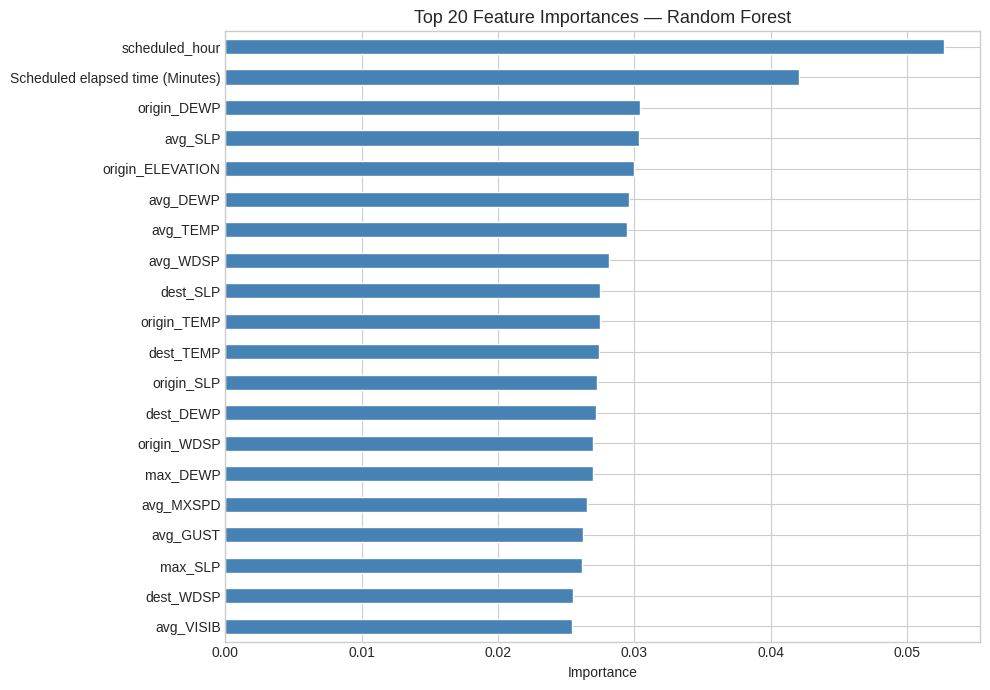

In [13]:
# Feature importance plot
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.head(20).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 20 Feature Importances — Random Forest', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

### 6b. Gradient Boosting

In [14]:
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=RANDOM_STATE)
gb.fit(X_train, y_train_enc)

gb_preds = gb.predict(X_test)
gb_acc = accuracy_score(y_test_enc, gb_preds)
gb_f1 = f1_score(y_test_enc, gb_preds, average='weighted')

print(f'Gradient Boosting — Accuracy: {gb_acc:.4f} | Weighted F1: {gb_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test_enc, gb_preds, target_names=le.classes_))

Gradient Boosting — Accuracy: 0.5248 | Weighted F1: 0.4921

Classification Report:
              precision    recall  f1-score   support

       Minor       0.55      0.79      0.65      3206
    Moderate       0.39      0.19      0.25      2057
      Severe       0.54      0.45      0.49      2037

    accuracy                           0.52      7300
   macro avg       0.49      0.47      0.46      7300
weighted avg       0.50      0.52      0.49      7300



### 6c. XGBoost

In [15]:
 xgb_model = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=6,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb_model.fit(X_train, y_train_enc)
xgb_preds = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test_enc, xgb_preds)
xgb_f1 = f1_score(y_test_enc, xgb_preds, average='weighted')
print(f'XGBoost — Accuracy: {xgb_acc:.4f} | Weighted F1: {xgb_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test_enc, xgb_preds, target_names=le.classes_))

XGBoost — Accuracy: 0.5227 | Weighted F1: 0.4919

Classification Report:
              precision    recall  f1-score   support

       Minor       0.55      0.78      0.65      3206
    Moderate       0.39      0.19      0.26      2057
      Severe       0.53      0.45      0.48      2037

    accuracy                           0.52      7300
   macro avg       0.49      0.47      0.46      7300
weighted avg       0.50      0.52      0.49      7300



### 6d. LightGBM

In [22]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=6,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
lgb_model.fit(X_train, y_train_enc)
lgb_preds = lgb_model.predict(X_test)
lgb_acc = accuracy_score(y_test_enc, lgb_preds)
lgb_f1 = f1_score(y_test_enc, lgb_preds, average='weighted')
print(f'LightGBM — Accuracy: {lgb_acc:.4f} | Weighted F1: {lgb_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test_enc, lgb_preds, target_names=le.classes_))

LightGBM — Accuracy: 0.5244 | Weighted F1: 0.4941

Classification Report:
              precision    recall  f1-score   support

       Minor       0.55      0.78      0.65      3206
    Moderate       0.38      0.19      0.25      2057
      Severe       0.54      0.46      0.50      2037

    accuracy                           0.52      7300
   macro avg       0.49      0.48      0.47      7300
weighted avg       0.50      0.52      0.49      7300



---
## 7. Model Comparison & Evaluation

In [23]:
# Build comparison table
results = {
    'Random Forest':      {'Accuracy': rf_acc,  'Weighted F1': rf_f1},
    'Gradient Boosting':  {'Accuracy': gb_acc,  'Weighted F1': gb_f1},
}
results['XGBoost'] = {'Accuracy': xgb_acc, 'Weighted F1': xgb_f1}
results['LightGBM'] = {'Accuracy': lgb_acc, 'Weighted F1': lgb_f1}

results_df = pd.DataFrame(results).T.sort_values('Weighted F1', ascending=False)
print('=== Model Comparison ===')
print(results_df.to_string())

=== Model Comparison ===
                   Accuracy  Weighted F1
LightGBM           0.524384     0.494115
Random Forest      0.500685     0.493310
Gradient Boosting  0.524795     0.492092
XGBoost            0.522740     0.491947


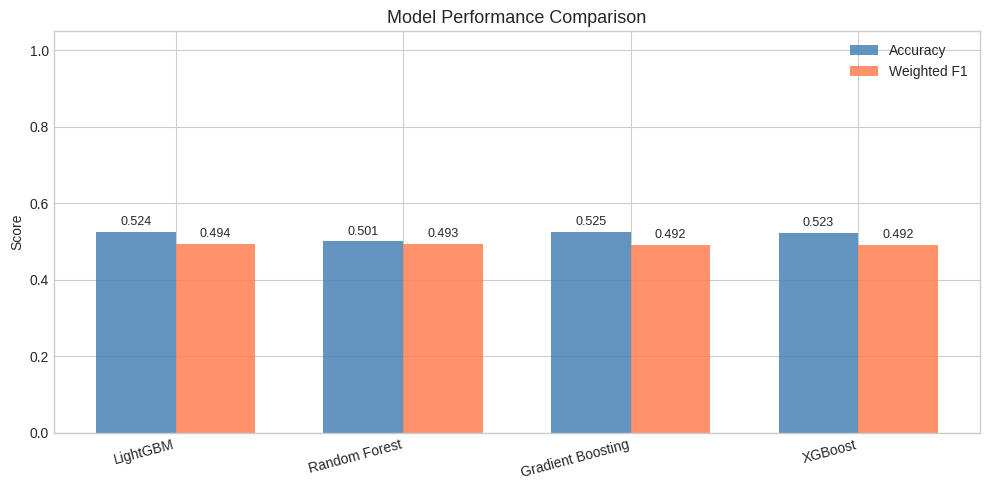

In [24]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, results_df['Weighted F1'], width, label='Weighted F1', color='coral', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_title('Model Performance Comparison', fontsize=13)
ax.set_ylabel('Score')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

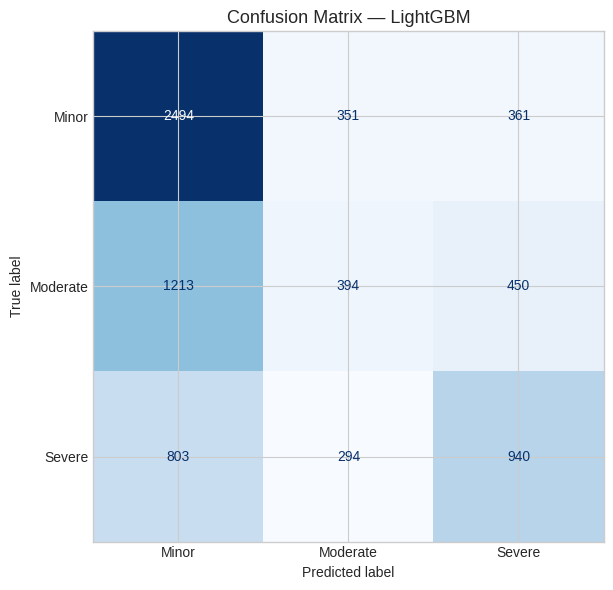


🏆 Best model: LightGBM
   Accuracy:    0.5244
   Weighted F1: 0.4941


In [25]:
# Confusion matrix for the best model
best_model_name = results_df.index[0]
best_preds_map = {
    'Random Forest': rf_preds,
    'Gradient Boosting': gb_preds,
    'Logistic Regression': lr_preds,
}
best_preds_map['XGBoost'] = xgb_preds
best_preds_map['LightGBM'] = lgb_preds

best_preds = best_preds_map[best_model_name]

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test_enc, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\n🏆 Best model: {best_model_name}')
print(f'   Accuracy:    {results_df.loc[best_model_name, "Accuracy"]:.4f}')
print(f'   Weighted F1: {results_df.loc[best_model_name, "Weighted F1"]:.4f}')

In [26]:
# Cross-validation on best tree-based model
print('Running 5-fold cross-validation on Random Forest...')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf, X_train, y_train_enc, cv=cv, scoring='f1_weighted', n_jobs=-1)
print(f'CV F1 Scores: {cv_scores.round(4)}')
print(f'Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Running 5-fold cross-validation on Random Forest...
CV F1 Scores: [0.5038 0.5016 0.5084 0.5062 0.5122]
Mean: 0.5064 ± 0.0037
